# NY Vir Newtonian N-Body Modeling
Demonstrates Newtonian N-body modeling using Rebound.

In [1]:
%load_ext autoreload
%autoreload 2
import os

In [2]:
from ocpy.data import Data

data = Data.from_file("../ny_vir_minima.xlsx")
data = data.fill_errors(0.0001).calculate_weights()

t0 = 2453174.442769
period = 0.1010159690

oc = data.calculate_oc(
    reference_minimum=t0,
    reference_period=period,
    model_type="pymc"
)

In [3]:
from ocpy.newtonian import NewtonianModel
from ocpy.oc import Parameter

nbody = NewtonianModel(
    central_mass=Parameter(value=0.611, fixed=True),
    T0_ref=t0,
    P_ref=period,
    bodies = [
        {
            "m":     Parameter(value=0.0021, fixed=False, std=1,  min=0),
            "P":     Parameter(value=3170.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.05,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=269.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2443302.0, fixed=False, std=3170.0), 
        },
        {
            "m":     Parameter(value=0.0038, fixed=False, std=1,  min=0),
            "P":     Parameter(value=8260.0, fixed=False, std=1000, min=0), 
            "e":     Parameter(value=0.02,   fixed=False, std=1,  min=0, max=.8),
            "omega": Parameter(value=140.0,  fixed=False, std=200, min=0, max=360),
            "T":     Parameter(value=2421163.0, fixed=False, std=8260.0), 
        }
    ],
    name="nbody"
)
models = [nbody]

Multiprocess sampling (4 chains in 4 jobs)
DEMetropolisZ: [nbody_b1_m, nbody_b1_P, nbody_b1_e, nbody_b1_omega, nbody_b1_T, nbody_b2_m, nbody_b2_P, nbody_b2_e, nbody_b2_omega, nbody_b2_T]


Output()

Sampling 4 chains for 2_000 tune and 2_000 draw iterations (8_000 + 8_000 draws total) took 943 seconds.
The rhat statistic is larger than 1.01 for some parameters. This indicates problems during sampling. See https://arxiv.org/abs/1903.08008 for details
The effective sample size per chain is smaller than 100 for some parameters.  A higher number is needed for reliable rhat and ess computation. See https://arxiv.org/abs/1903.08008 for details


<Axes: ylabel='O−C'>

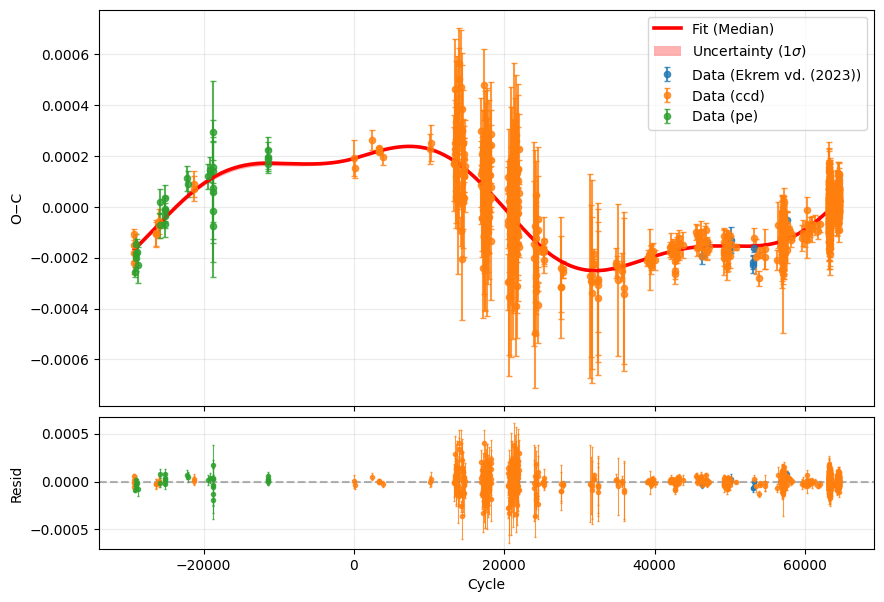

In [4]:
from pymc import DEMetropolisZ
res = oc.fit(models, tune=2000, draws=2000, chains=4)
oc.plot(res)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

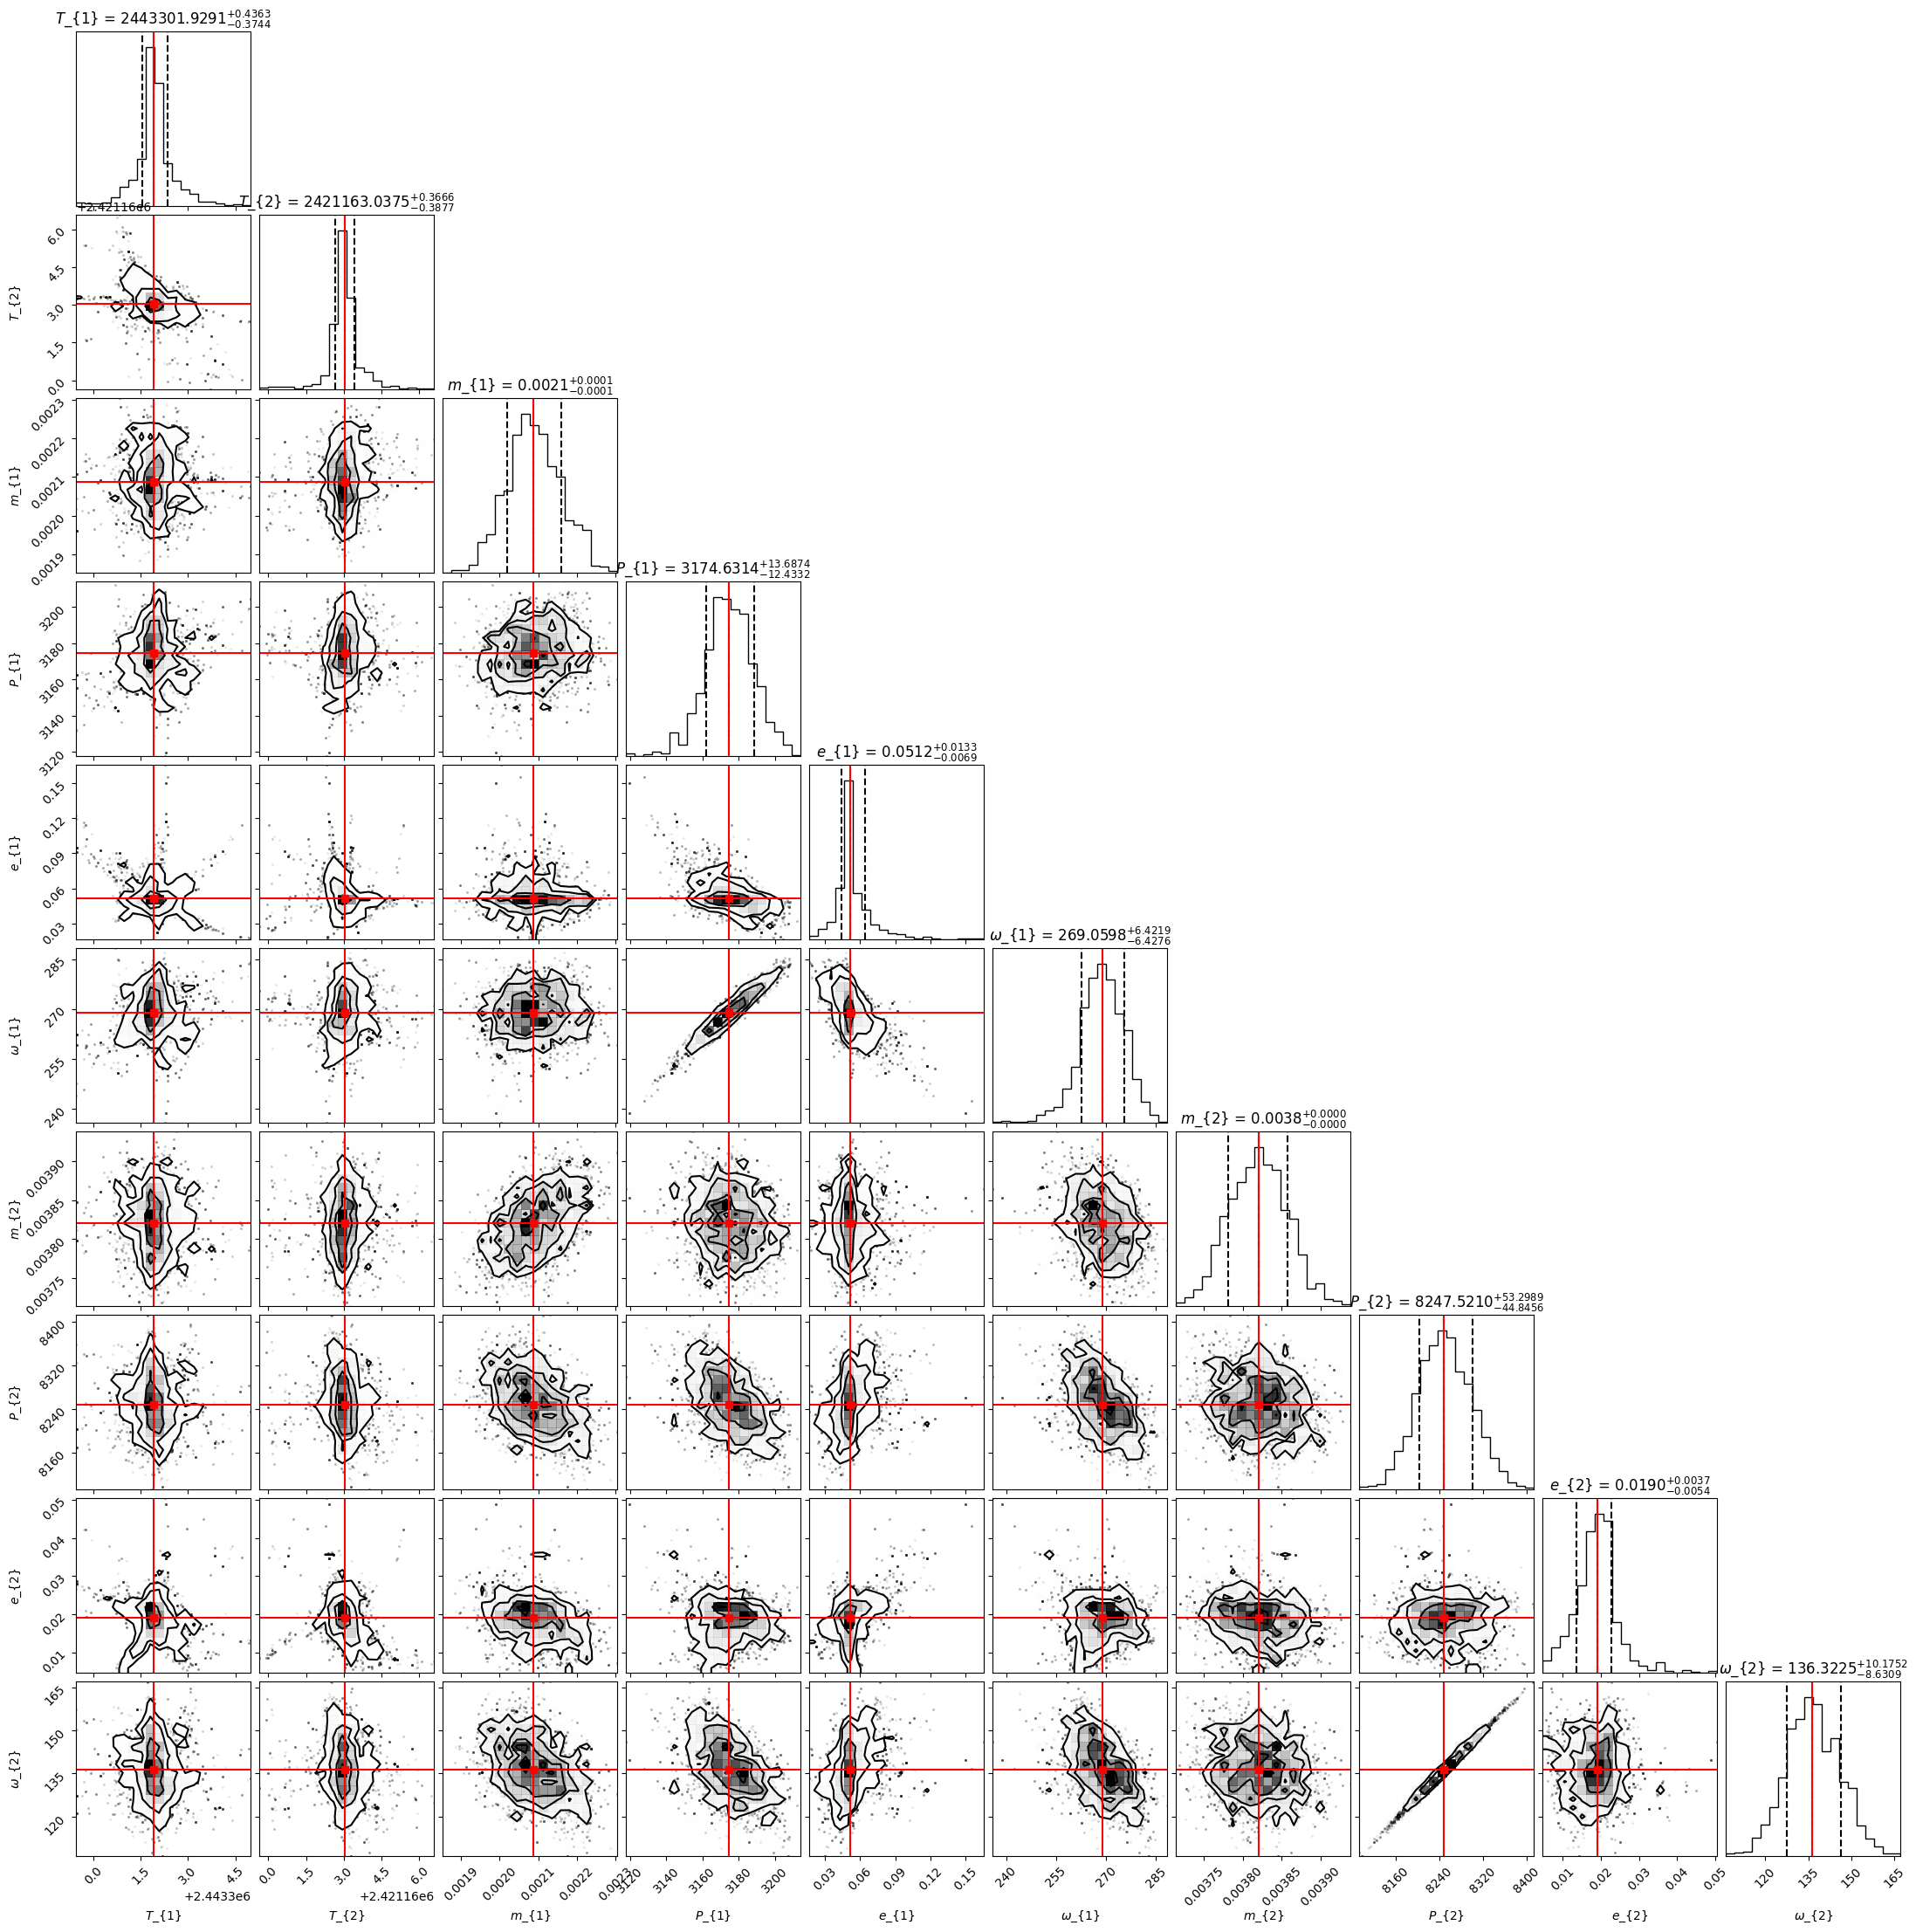

In [5]:
oc.corner(res)
res

In [6]:
cleaned_res = oc.clean(res)

Inference data with groups:
	> posterior
	> sample_stats
	> observed_data

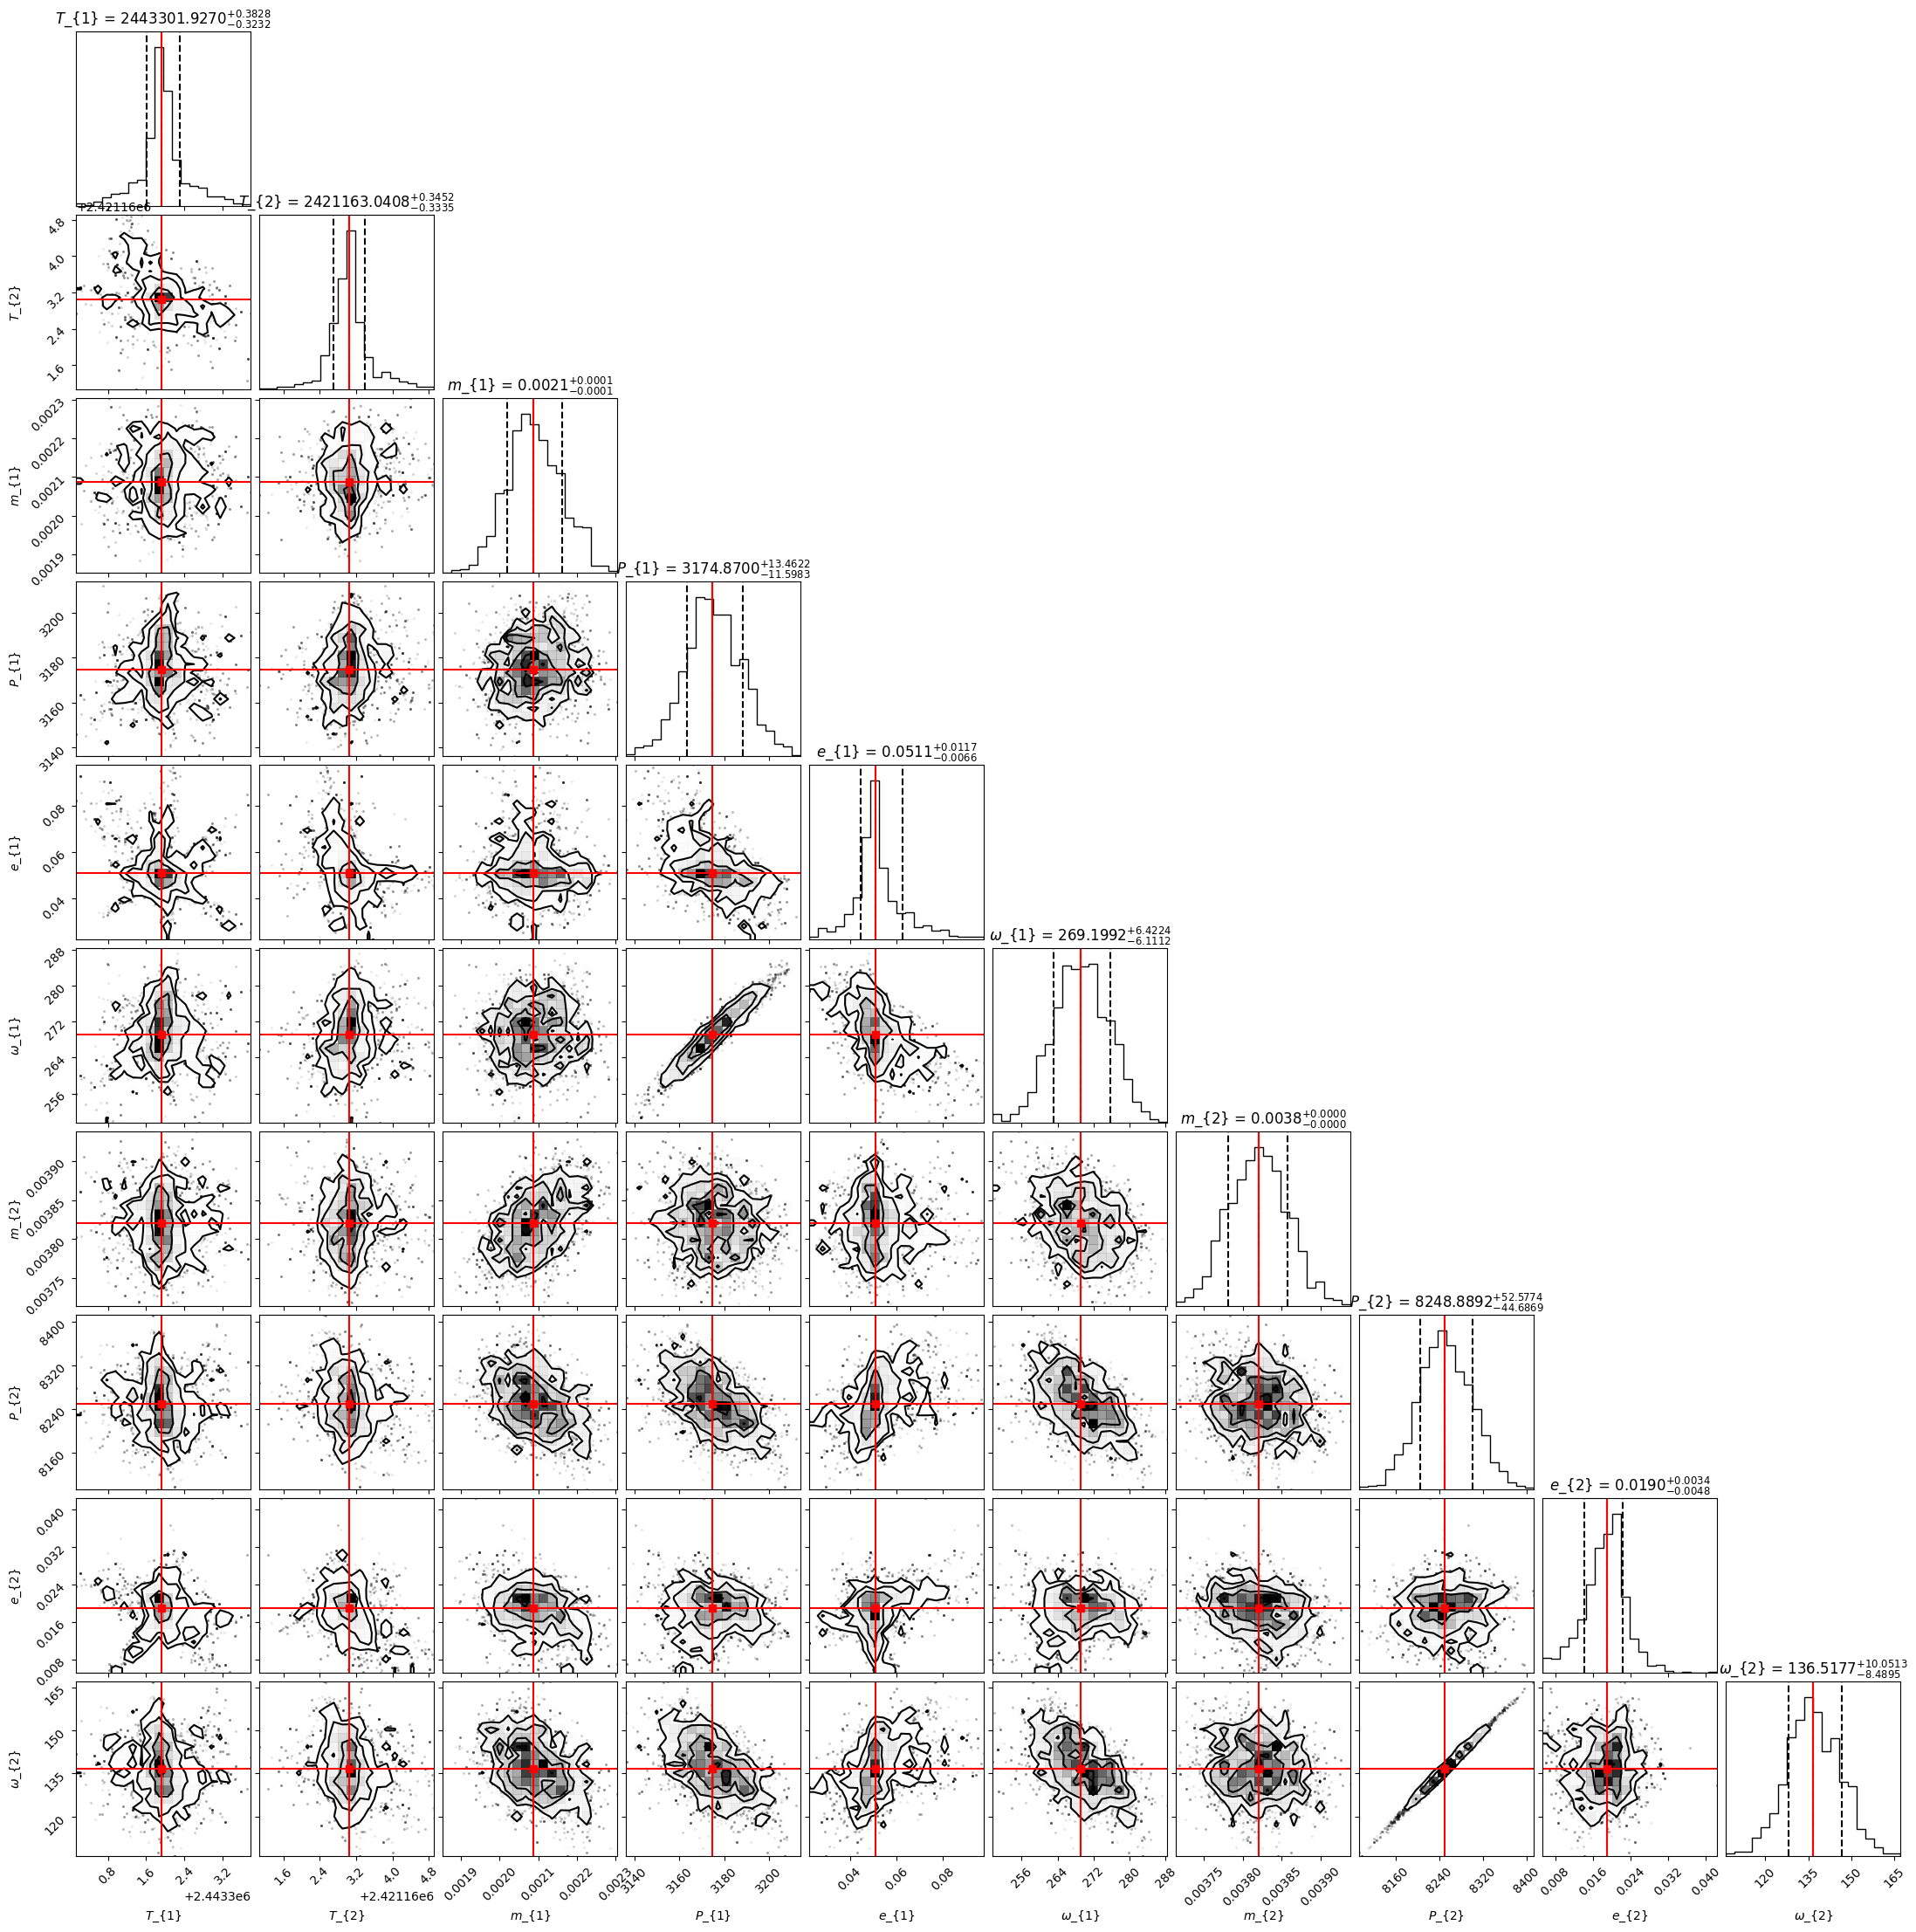

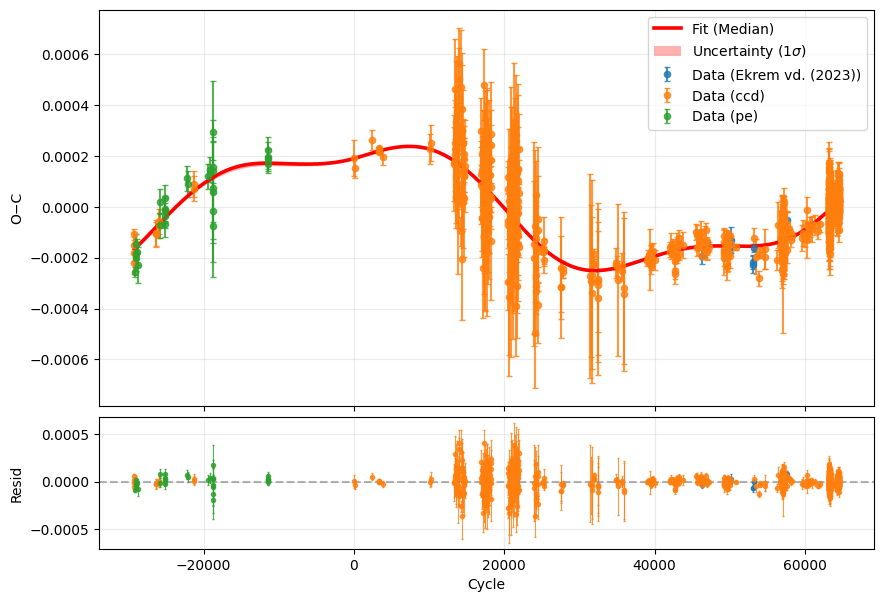

In [7]:
oc.corner(cleaned_res)
oc.plot(cleaned_res)
res